In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.decomposition import FactorAnalysis
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import matplotlib.pyplot as plt
import seaborn as sns
import os
pd.options.display.max_columns = 70

In [2]:
data_raw = pd.read_csv('./IPIP-FFM-data-8Nov2018/data-final.csv', sep='\t')

#Select columns to only keep the 50 items that measure the 5 personality traits. 
#See codebook.txt for more details on all the columns.
data = data_raw.iloc[:, :50]

#We remove all lines where IPC is not 1, as these could be multiple submissions of the same person.
#The total number of lines in the original dataset is 1 015 341, and 696 845 after cleaning.
print("Number lines removed to avoid multiple submission : ", np.sum(data_raw.IPC != 1))
data = data[data_raw.IPC == 1]

#We remove lines where data is missing
n_before = len(data)
data = data.dropna()
n_after = len(data)
print("Number lines removed to avoid missing data : ", n_before - n_after)

#NE GARDE QUE LE 100 000 PREMIERS LIGNES POUR ACCELERER LES CALCULS (A enlever pour l'analyse finale)
data = data.iloc[:100000, :]

data

Number lines removed to avoid multiple submission :  318496
Number lines removed to avoid missing data :  1141


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,EST1,EST2,EST3,EST4,EST5,EST6,EST7,EST8,EST9,EST10,AGR1,AGR2,AGR3,AGR4,AGR5,AGR6,AGR7,AGR8,AGR9,AGR10,CSN1,CSN2,CSN3,CSN4,CSN5,CSN6,CSN7,CSN8,CSN9,CSN10,OPN1,OPN2,OPN3,OPN4,OPN5,OPN6,OPN7,OPN8,OPN9,OPN10
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,1.0,4.0,4.0,2.0,2.0,2.0,2.0,2.0,3.0,2.0,2.0,5.0,2.0,4.0,2.0,3.0,2.0,4.0,3.0,4.0,3.0,4.0,3.0,2.0,2.0,4.0,4.0,2.0,4.0,4.0,5.0,1.0,4.0,1.0,4.0,1.0,5.0,3.0,4.0,5.0
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,2.0,3.0,4.0,1.0,3.0,1.0,2.0,1.0,3.0,1.0,1.0,4.0,1.0,5.0,1.0,5.0,3.0,4.0,5.0,3.0,3.0,2.0,5.0,3.0,3.0,1.0,3.0,3.0,5.0,3.0,1.0,2.0,4.0,2.0,3.0,1.0,4.0,2.0,5.0,3.0
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,4.0,4.0,4.0,2.0,2.0,2.0,2.0,2.0,1.0,3.0,1.0,4.0,1.0,4.0,2.0,4.0,1.0,4.0,4.0,3.0,4.0,2.0,2.0,2.0,3.0,3.0,4.0,2.0,4.0,2.0,5.0,1.0,2.0,1.0,4.0,2.0,5.0,3.0,4.0,4.0
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,3.0,3.0,3.0,2.0,3.0,2.0,2.0,2.0,4.0,3.0,2.0,4.0,3.0,4.0,2.0,4.0,2.0,4.0,3.0,4.0,2.0,4.0,4.0,4.0,1.0,2.0,2.0,3.0,1.0,4.0,4.0,2.0,5.0,2.0,3.0,1.0,4.0,4.0,3.0,3.0
5,3.0,3.0,4.0,2.0,4.0,2.0,2.0,3.0,3.0,4.0,3.0,4.0,3.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,3.0,1.0,4.0,2.0,3.0,2.0,3.0,4.0,4.0,3.0,2.0,4.0,1.0,3.0,2.0,4.0,3.0,4.0,3.0,5.0,1.0,5.0,1.0,3.0,1.0,5.0,4.0,5.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136585,1.0,4.0,2.0,4.0,3.0,3.0,2.0,4.0,2.0,4.0,4.0,3.0,4.0,2.0,3.0,3.0,3.0,3.0,4.0,4.0,3.0,3.0,3.0,4.0,2.0,4.0,4.0,3.0,2.0,3.0,3.0,4.0,4.0,4.0,2.0,5.0,3.0,4.0,3.0,2.0,4.0,3.0,2.0,4.0,4.0,4.0,2.0,4.0,5.0,2.0
136586,1.0,2.0,3.0,1.0,3.0,1.0,5.0,3.0,4.0,5.0,4.0,3.0,5.0,1.0,1.0,3.0,4.0,3.0,3.0,5.0,1.0,5.0,4.0,5.0,1.0,3.0,1.0,4.0,4.0,5.0,3.0,2.0,5.0,1.0,2.0,1.0,5.0,2.0,3.0,3.0,5.0,1.0,5.0,1.0,5.0,1.0,4.0,4.0,5.0,5.0
136588,2.0,2.0,3.0,3.0,4.0,2.0,2.0,3.0,3.0,3.0,3.0,2.0,4.0,2.0,3.0,2.0,3.0,3.0,2.0,3.0,1.0,4.0,2.0,4.0,2.0,4.0,2.0,4.0,4.0,4.0,3.0,4.0,3.0,2.0,2.0,4.0,3.0,2.0,3.0,4.0,4.0,2.0,4.0,1.0,4.0,2.0,4.0,4.0,5.0,4.0
136589,1.0,4.0,5.0,3.0,2.0,3.0,1.0,5.0,1.0,5.0,3.0,2.0,4.0,3.0,5.0,4.0,5.0,5.0,4.0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,1.0,5.0,5.0,5.0,5.0,2.0,5.0,2.0,4.0,1.0,5.0,3.0,5.0,5.0,0.0,1.0,5.0,2.0,5.0,1.0,5.0,5.0,5.0,5.0


## Factor analysis

We perform factor analysis on the data to reduce the dimensionnality of the data. In pychological terms, it means that to find the underlying fundamental personality traits that explain the responses to the questions.

### Note on rotation

We apply factor analysis to the data, to extract the 5 personality traits, with varimax rotation to make the traits more interpretable.

We could have used non orthogonal rotation methods, like oblimin which allow for correlated factors. It is commonly recommended to use oblique rotation in psychometric analysis, as said in Fabrigar et al. (https://doi.org/10.1037/1082-989X.4.3.272): for many constructs examined in psychology (e.g., mental abilities, personality traits, attitudes), there is substantial theoretical and empirical basis for expecting these constructs (or dimensions of these constructs) to be correlated with one another. Therefore, oblique rotations provide a more accurate and realistic representation of how constructs are likely to be related to one another.

However, our goal here is not to explain the correlations between factors, but to perform clustering on the factors, and we fear that oblique rotation will deform the space in way that will influence the clustering. [MAYBE NOT FOR FULL MATRIX GMM, TO CHECK]
And additionally Costello et Osborne (https://doi.org/10.1037/1082-989X.4.3.272) suggest that orthogonal and oblique rotation often produce similar results.

### Note on the factor analysis extraction method

FactorAnalysis from sklearn use the maximum likelihood method to perform factor analysis, which assume that factors are normally distributed. 
This directly contradicts the assumption of the gaussian mixture model that we will use later. However, this don't seem to bother Gerlach, M., Farb, B., Revelle, W. et al. (https://doi.org/10.1038/s41562-018-0419-z).
There exists other extraxtion methods for factor analysis, like unweighted least squares (ULS), which do not assume normality of the factors. However, this method is not implemented in sklearn.

In [ ]:
data_np = data.to_numpy()

fa = FactorAnalysis(n_components=5, rotation='varimax')

#We create a new dataframe with the 5 personality traits as columns, and the same index as the original data.
#Name the columns with the 5 factors, according to the questions that have the highest weights on each factor.
#Recall that question are ordered as follows : Ext,Est,Agr,Csn,Opn and that eaqvh trait have 10 questions.

data_fa = pd.DataFrame(fa.fit_transform(data_np))
data_fa

,0,1,2,3,4
0,-1.681330,0.701510,0.185593,-0.639684,-0.275974
1,1.162020,0.893780,-1.231598,0.642508,0.416021
2,0.617773,0.887801,-0.668067,0.072072,0.069958
3,0.253794,0.401381,-0.102094,0.123979,-1.223521
4,-0.054589,1.155843,-0.056698,-0.034418,0.260434
...,...,...,...,...,...
99995,0.815736,-0.546898,0.516167,0.975687,-0.663132
99996,-0.505914,-0.421645,-0.654428,-1.098040,0.288581
99997,-0.132685,0.193208,-0.401977,-0.222794,-0.481442
99998,0.734376,-1.080538,-1.437332,-0.830041,1.499244


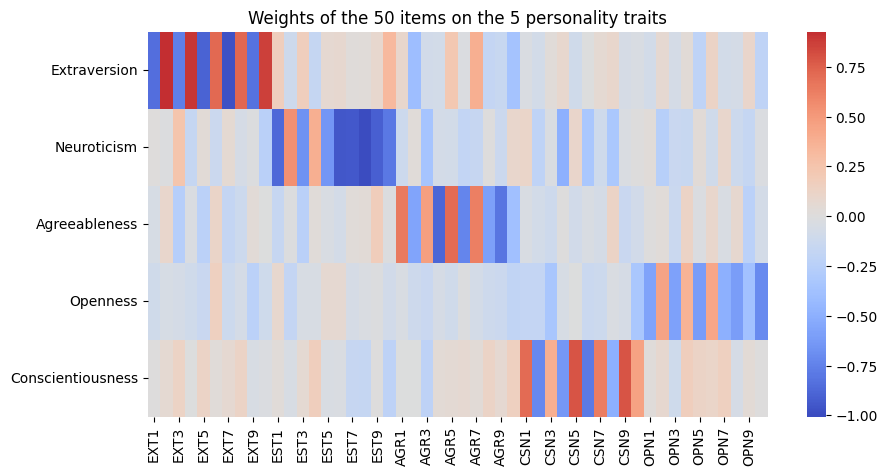

In [4]:
#plot the weights of the 50 items on the 5 personality traits as a heatmap
weights = pd.DataFrame(fa.components_, columns=data.columns, index=['Extraversion','Neuroticism','Agreeableness','Openness','Conscientiousness'])
plt.figure(figsize=(10, 5))
sns.heatmap(weights, cmap='coolwarm', center=0)
plt.title('Weights of the 50 items on the 5 personality traits')
plt.show()

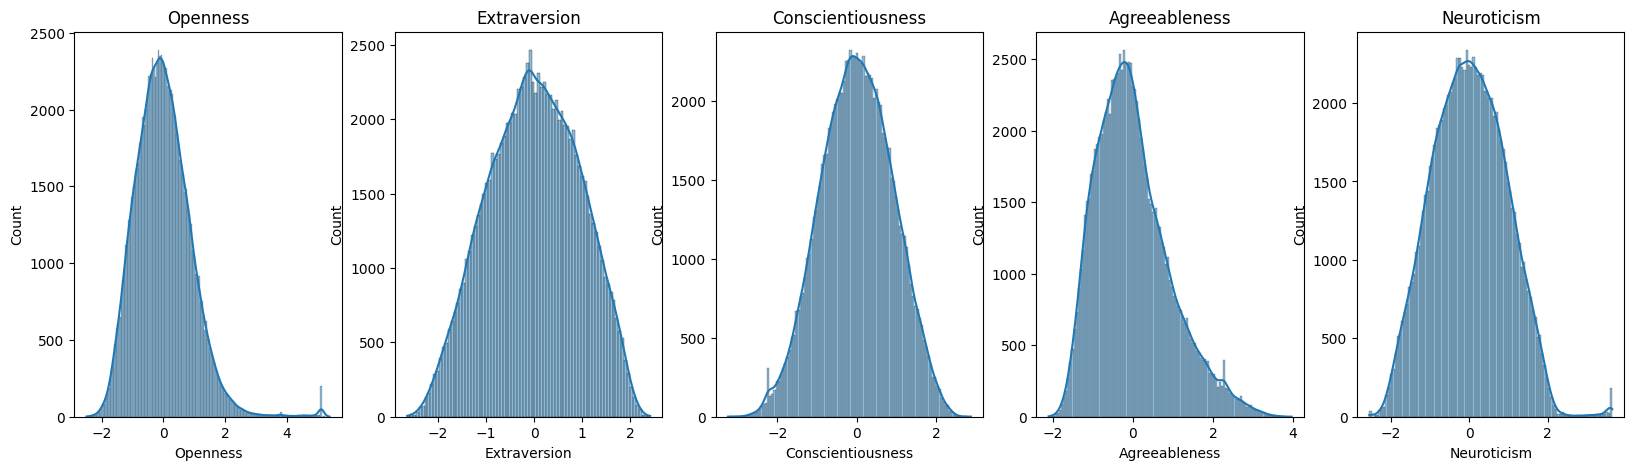

In [5]:
#From the previous plot, we can see that factor are ordered as follows:
data_fa.columns = ['Extraversion','Neuroticism','Agreeableness','Openness','Conscientiousness']
#plot the distribution of the 5 personality traits in 5 subplots
fig, axs = plt.subplots(1, 5, figsize=(20, 5))
sns.histplot(data_fa['Openness'], ax=axs[0], kde=True)
sns.histplot(data_fa['Conscientiousness'], ax=axs[2], kde=True)
sns.histplot(data_fa['Extraversion'], ax=axs[1], kde=True)
sns.histplot(data_fa['Agreeableness'], ax=axs[3], kde=True)
sns.histplot(data_fa['Neuroticism'], ax=axs[4], kde=True)
axs[0].set_title('Openness')
axs[2].set_title('Conscientiousness')
axs[1].set_title('Extraversion')
axs[3].set_title('Agreeableness')
axs[4].set_title('Neuroticism')
plt.show()